<a href="https://colab.research.google.com/github/rotoncsedu/DL/blob/main/Reuters_Multi_class_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)
print(len(train_data))
print(len(test_data))

8982
2246


In [5]:
## Reverse Encoding

In [7]:
word_index = reuters.get_word_index()
reverse_word_index = dict(
    [(value,key) for (key,value) in word_index.items()]
)
decoded_newswire = ' '.join(
    [reverse_word_index.get(i-3,'?') for i in train_data[0]]
)
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [9]:
## Multi-hot Vectorization

In [10]:
import numpy as np
def vectorize_sequence(sequence, dimensions = 10000):
  results = np.zeros((len(sequence), dimensions))
  for i, seq in enumerate(sequence):
    for j in seq:
      results[i, j] = 1
  return results
X_train = vectorize_sequence(train_data)
X_test = vectorize_sequence(test_data)
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [8]:
## One-hot Vectorization

In [15]:
def one_hot_vec(labels, dimension = 46):
  results = np.zeros((len(labels),dimension))
  for i, label in enumerate(labels):
    results[i, label] = 1
  return results
one_hot_train_labels = one_hot_vec(train_labels)
one_hot_test_labels = one_hot_vec(test_labels)
one_hot_train_labels[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [20]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
  layers.Dense(64, activation = 'relu'),
  layers.Dense(64, activation = 'relu'),
  layers.Dense(46, activation = 'softmax')
])

In [21]:
model.compile(
    optimizer = "rmsprop",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [22]:
X_val = X_train[:1000]
partial_X_train = X_train[1000:]
y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

In [23]:
History = model.fit(
    partial_X_train,
    partial_y_train,
    epochs = 20,
    batch_size = 512,
    validation_data = (X_val, y_val)
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4964 - loss: 2.7109 - val_accuracy: 0.6380 - val_loss: 1.8035
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6874 - loss: 1.4924 - val_accuracy: 0.6880 - val_loss: 1.3504
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7496 - loss: 1.1439 - val_accuracy: 0.7550 - val_loss: 1.1795
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.7962 - loss: 0.9316 - val_accuracy: 0.7420 - val_loss: 1.1101
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8310 - loss: 0.7739 - val_accuracy: 0.7560 - val_loss: 1.0545
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8601 - loss: 0.6439 - val_accuracy: 0.7940 - val_loss: 0.9662
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8805 - loss: 0.5402 - val_accuracy: 0.8130 - val_loss: 0.9254
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9042 - loss: 0.4491 - val_accuracy: 0.8050 - v

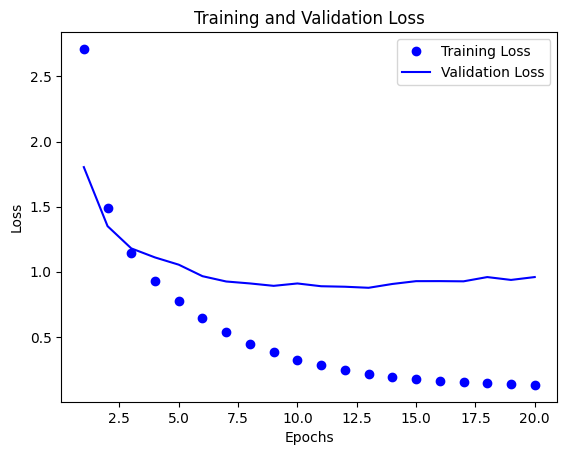

In [24]:
loss = History.history['loss']
val_loss = History.history['val_loss']
epochs = range(1, len(loss) + 1)
import matplotlib.pyplot as plt
plt.plot(epochs, loss, 'bo', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

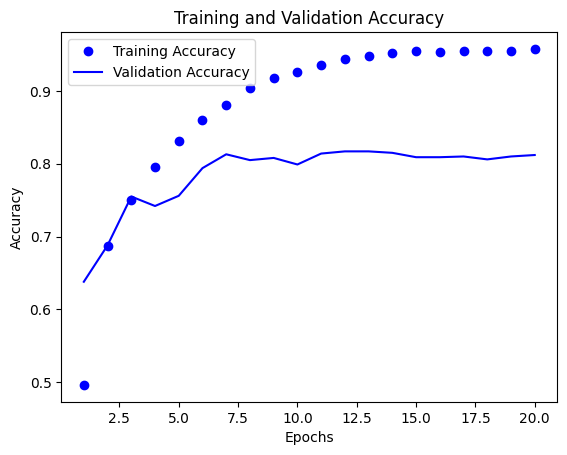

In [25]:
acc= History.history['accuracy']
val_acc = History.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label = 'Training Accuracy')
plt.plot(epochs, val_acc, 'b', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
model = keras.Sequential([
  layers.Dense(64, activation = 'relu'),
  layers.Dense(64, activation = 'relu'),
  layers.Dense(46, activation = 'softmax')
])
model.compile(
    optimizer = "rmsprop",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)
model.fit(
    partial_X_train,
    partial_y_train,
    epochs = 9,
    batch_size = 512,
    validation_data = (X_val, y_val)
)
results = model.evaluate(X_test, one_hot_test_labels)

Epoch 1/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.4551 - loss: 2.7005 - val_accuracy: 0.6360 - val_loss: 1.8237
Epoch 2/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6763 - loss: 1.5439 - val_accuracy: 0.6780 - val_loss: 1.4099
Epoch 3/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.7432 - loss: 1.1859 - val_accuracy: 0.7300 - val_loss: 1.1900
Epoch 4/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7919 - loss: 0.9630 - val_accuracy: 0.7760 - val_loss: 1.0754
Epoch 5/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8289 - loss: 0.7942 - val_accuracy: 0.7890 - val_loss: 1.0007
Epoch 6/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.8631 - loss: 0.6585 - val_accuracy: 0.7930 - val_loss: 0.9644
Epoch 7/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8835 - loss: 0.5528 - val_accuracy: 0.8110 - val_loss: 0.9232
Epoch 8/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9038 - loss: 0.4594 - val_accuracy: 0.8120 - val_loss: